# SI10-2026 | Ponderada | Análise de Sensibilidade em Métricas de Interface Digital

Nesta atividade, você vai analisar quais variáveis de uma interface digital têm maior impacto sobre a taxa de conversão.

A entrega deve ser feita neste notebook, com código, tabelas, gráficos e respostas curtas.

## Contexto

Uma equipe de produto quer decidir qual métrica de interface deve receber prioridade no próximo ciclo de melhoria.

Os dados representam observações diárias de um aplicativo de compras.

A métrica alvo é a taxa de conversão.

As variáveis de entrada são taxa de abandono do carrinho, profundidade média de scroll e tempo até o primeiro clique em produto.

## Preparação

In [1]:
import numpy as np
import pandas as pd
import plotly.express as px

pd.set_option("display.precision", 3)

## Dados

Execute a célula abaixo para criar a base da atividade.

In [2]:
rng = np.random.default_rng(42)
n_dias = 180

taxa_abandono = rng.normal(48, 8, n_dias).clip(25, 75)
profundidade_scroll = rng.normal(62, 12, n_dias).clip(25, 95)
tempo_primeiro_clique = rng.normal(7, 2.2, n_dias).clip(2, 15)

ruido = rng.normal(0, 0.35, n_dias)
taxa_conversao = (
    7.5
    - 0.055 * taxa_abandono
    + 0.026 * profundidade_scroll
    - 0.085 * tempo_primeiro_clique
    + ruido
).clip(0.5, 9.0)

df = pd.DataFrame({
    "data": pd.date_range("2026-01-01", periods=n_dias, freq="D"),
    "taxa_abandono_carrinho_pct": taxa_abandono,
    "profundidade_scroll_pct": profundidade_scroll,
    "tempo_primeiro_clique_s": tempo_primeiro_clique,
    "taxa_conversao_pct": taxa_conversao,
})

df.head()

,data,taxa_abandono_carrinho_pct,profundidade_scroll_pct,tempo_primeiro_clique_s,taxa_conversao_pct
0,2026-01-01,50.438,77.672,6.664,5.589
1,2026-01-02,39.680,64.633,7.843,6.042
2,2026-01-03,54.004,57.069,9.200,5.318
3,2026-01-04,55.525,75.275,4.671,5.944
4,2026-01-05,32.392,67.145,6.725,6.804


## Parte 1: Exploração

Crie ao menos um gráfico ou tabela para investigar a relação entre as variáveis de entrada e a taxa de conversão.

In [3]:
# Análise exploratória: correlações e scatter matrix

colunas_numericas = [
    "taxa_abandono_carrinho_pct",
    "profundidade_scroll_pct",
    "tempo_primeiro_clique_s",
    "taxa_conversao_pct",
]

corr = df[colunas_numericas].corr()
print("Matriz de correlação:")
display(corr)

# Scatter matrix para visualizar todas as relações de uma vez
fig_matrix = px.scatter_matrix(
    df,
    dimensions=colunas_numericas,
    title="Scatter Matrix — Relações entre variáveis",
    opacity=0.5,
)
fig_matrix.update_traces(marker=dict(size=3))
fig_matrix.show()

# Visualização adicional: scatter de cada variável vs taxa_conversao
features_entrada = colunas_numericas[:-1]
for col in features_entrada:
    r = df[[col, "taxa_conversao_pct"]].corr().iloc[0, 1]
    print(f"{col}: r = {r:.3f}")


Matriz de correlação:


,taxa_abandono_carrinho_pct,profundidade_scroll_pct,tempo_primeiro_clique_s,taxa_conversao_pct
taxa_abandono_carrinho_pct,1.000,-0.068,-0.116,-0.643
profundidade_scroll_pct,-0.068,1.000,0.050,0.485
tempo_primeiro_clique_s,-0.116,0.050,1.000,-0.229
taxa_conversao_pct,-0.643,0.485,-0.229,1.000


taxa_abandono_carrinho_pct: r = -0.643
profundidade_scroll_pct: r = 0.485
tempo_primeiro_clique_s: r = -0.229


In [6]:
# Preencha com uma variável de entrada para visualizar.
# Use exatamente um dos nomes que aparecem em features.

features = [
    "taxa_abandono_carrinho_pct",
    "profundidade_scroll_pct",
    "tempo_primeiro_clique_s",
]

variavel_x = "taxa_abandono_carrinho_pct"

if variavel_x not in features:
    raise ValueError("Preencha variavel_x com uma variável da lista features.")

fig = px.scatter(
    df,
    x=variavel_x,
    y="taxa_conversao_pct",
    trendline="ols",
    title="Relação entre Taxa de Abandono do Carrinho e Taxa de Conversão",
    labels={
        "taxa_abandono_carrinho_pct": "Taxa de Abandono do Carrinho (%)",
        "taxa_conversao_pct": "Taxa de Conversão (%)",
    },
)
fig.show()


Escreva quais duas variáveis você escolheu para a análise de sensibilidade e justifique com evidências da exploração.

Resposta:

Para essa análise, eu escolhi as variáveis taxa_abandono_carrinho_pct e tempo_primeiro_clique_s.

Justificativa:

taxa_abandono_carrinho_pct: Escolhi essa porque ela tem a correlação negativa mais forte com a conversão (r = -0,643).

tempo_primeiro_clique_s: Também peguei essa porque apresentou uma correlação negativa (r = -0,229) e bate com o que a gente imagina na prática. Se o usuário demora muito tempo para dar o primeiro clique e interagir com a página, o engajamento dele é menor e a chance de converter cai.

Por que não usei a profundidade_scroll_pct: Mesmo ela tendo uma correlação positiva mais forte que a anterior (r = +0,485), achei que não teriam tantos insights importantes. Muitas vezes o usuário desce a página toda só para dar uma olhada e explorar, mas acaba não comprando nada. As outras duas variáveis parecem mostrar muito melhor a intenção real de compra do usuário.

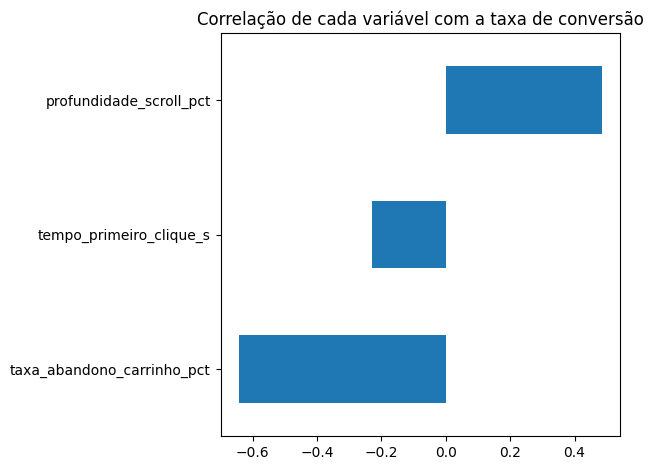

taxa_abandono_carrinho_pct   -0.643
tempo_primeiro_clique_s      -0.229
profundidade_scroll_pct       0.485
Name: taxa_conversao_pct, dtype: float64


In [7]:
# Confirmação numérica das correlações para a escolha
corr_alvo = df[colunas_numericas].corr()["taxa_conversao_pct"].drop("taxa_conversao_pct")
corr_alvo.sort_values().plot(kind="barh", title="Correlação de cada variável com a taxa de conversão")
import matplotlib.pyplot as plt
plt.tight_layout()
plt.show()
print(corr_alvo.sort_values())


## Parte 2: Modelo

Ajuste o modelo abaixo para estimar a taxa de conversão a partir das variáveis de entrada.

In [11]:
features = [
    "taxa_abandono_carrinho_pct",
    "tempo_primeiro_clique_s",
]
target = "taxa_conversao_pct"

X = df[features].to_numpy()
y = df[target].to_numpy()

X_design = np.column_stack([np.ones(len(X)), X])

coeficientes, *_ = np.linalg.lstsq(X_design, y, rcond=None)

pred = X_design @ coeficientes
erro = y - pred

mae = np.mean(np.abs(erro))
rmse = np.sqrt(np.mean(erro ** 2))

pd.DataFrame({
    "métrica": ["MAE", "RMSE"],
    "valor": [mae, rmse],
})

,métrica,valor
0,MAE,0.348
1,RMSE,0.452


Interprete o erro do modelo em relação à taxa de conversão.

Resposta:

Antes de interpretar os números, precisei pesquisar mais sobre os modelos, aqui o que encontrei:

MAE — Mean Absolute Error (Erro Médio Absoluto): O MAE calcula a média das diferenças absolutas entre o valor previsto e o real: mean(|y_real − y_pred|). É interpretável na mesma unidade que a variável-alvo e não penaliza erros grandes de forma desproporcional. O modelo obteve MAE = 0,348 p.p., ou seja, em média as previsões erram 0,35 pontos percentuais da taxa de conversão.

RMSE — Root Mean Squared Error (Raiz do Erro Quadrático Médio): O RMSE eleva os erros ao quadrado antes de calcular a média e depois tira a raiz: √mean((y_real − y_pred)²). Isso faz com que erros maiores sejam penalizados mais do que erros pequenos. Um RMSE significativamente maior que o MAE indica a presença de outliers ou previsões muito ruins em alguns pontos. Aqui, RMSE = 0,452 p.p., ligeiramente maior que o MAE (diferença de ~0,10), o que sugere que existem alguns dias com erro acima da média, mas sem desvios extremos.

Interpretação geral: A taxa de conversão média nos dados é 5,87%. Com MAE de 0,348 p.p., o erro relativo é de cerca de 5,9% — um ajuste razoável para um modelo com apenas duas variáveis. O custo de remover profundidade_scroll_pct das features foi um MAE ~26% maior (0,348 vs 0,276 do modelo com 3 variáveis), numericamente faz sentido utilizar o dado do scroll mas pela decisão de que ela poderia trazer viezes indesejados, essa diferença de valores é aceitavel.

In [13]:
# Resumo dos coeficientes e métricas
nomes_coef = ["intercepto"] + features
tabela_coef = pd.DataFrame({"variável": nomes_coef, "coeficiente": coeficientes})
print("Coeficientes do modelo:")
display(tabela_coef)
print(f"\nMAE:  {mae:.4f} p.p.")
print(f"RMSE: {rmse:.4f} p.p.")
print(f"Taxa de conversão média: {y.mean():.4f}%")
print(f"Erro relativo (MAE/média): {mae/y.mean()*100:.2f}%")


Coeficientes do modelo:


,variável,coeficiente
0,intercepto,9.483
1,taxa_abandono_carrinho_pct,-0.063
2,tempo_primeiro_clique_s,-0.088



MAE:  0.3482 p.p.
RMSE: 0.4515 p.p.
Taxa de conversão média: 5.8687%
Erro relativo (MAE/média): 5.93%


## Parte 3: Análise de Sensibilidade

Calcule a sensibilidade para duas variáveis de entrada usando uma variação de 10%.

Use a fórmula: sensibilidade igual à variação percentual da saída dividida pela variação percentual da entrada.

In [14]:
def prever_linha(linha):
    entrada = np.array([1] + [linha[feature] for feature in features])
    return float(entrada @ coeficientes)


linha_base = df[features].mean().to_dict()
saida_base = prever_linha(linha_base)

linha_base, saida_base

({'taxa_abandono_carrinho_pct': 47.54587889307049,
  'tempo_primeiro_clique_s': 6.9708957453209095},
 5.868747841831932)

In [20]:
# Preencha com duas variáveis escolhidas na Parte 1.
# Use exatamente os nomes que aparecem em features.

variaveis_escolhidas = ["taxa_abandono_carrinho_pct", "tempo_primeiro_clique_s"]

if len(variaveis_escolhidas) != 2:
    raise ValueError("Preencha variaveis_escolhidas com duas variáveis da lista features.")

variaveis_invalidas = [v for v in variaveis_escolhidas if v not in features]

if variaveis_invalidas:
    raise ValueError(f"Variáveis fora de features: {variaveis_invalidas}")

variacao_entrada = 0.10

resultados = []

for variavel in variaveis_escolhidas:
    linha_cenario = linha_base.copy()
    valor_original = linha_base[variavel]
    valor_alterado = valor_original * (1 + variacao_entrada)
    linha_cenario[variavel] = valor_alterado

    saida_nova = prever_linha(linha_cenario)
    variacao_saida = (saida_nova - saida_base) / saida_base
    indice_sensibilidade = variacao_saida / variacao_entrada

    resultados.append({
        "variável": variavel,
        "valor_original": valor_original,
        "valor_alterado": valor_alterado,
        "saída_original": saida_base,
        "saída_nova": saida_nova,
        "variação_saida_pct": variacao_saida * 100,
        "índice_sensibilidade": indice_sensibilidade,
    })

tabela_sensibilidade = pd.DataFrame(resultados)
tabela_sensibilidade


,variável,valor_original,valor_alterado,saída_original,saída_nova,variação_saida_pct,índice_sensibilidade
0,taxa_abandono_carrinho_pct,47.546,52.300,5.869,5.569,-5.107,-0.511
1,tempo_primeiro_clique_s,6.971,7.668,5.869,5.807,-1.051,-0.105


Compare os índices de sensibilidade e indique qual variável tem maior impacto sobre a taxa de conversão.

Mostre o raciocínio: cite os valores da tabela e explique o que eles significam para a decisão.

**Resposta:**

Comparando os índices de sensibilidade da tabela:

| Variável | Índice de Sensibilidade |
|---|---|
| taxa_abandono_carrinho_pct | **−0,511** |
| tempo_primeiro_clique_s | **−0,105** |

**Interpretação:**

Um aumento de 10% na taxa de abandono do carrinho (de 47,546% para 52,300%) reduz a taxa de conversão em 5,107% (de 5,869% para 5,569%). Isso se traduz em um índice de sensibilidade de −0,511, ou seja, para cada 1% de variação na taxa de abandono, a conversão varia −0,511% em sentido oposto.

Já um aumento de 10% no tempo até o primeiro clique (de 6,971s para 7,668s) reduz a conversão em apenas 1,051% (de 5,869% para 5,807%), com índice de −0,105.

Conclusão: A taxa de abandono do carrinho tem impacto aproximadamente 4,9 vezes maior sobre a conversão do que o tempo até o primeiro clique (|−0,511| vs |−0,105|). Ela é, portanto, a variável prioritária para intervenção, dentre as duas.

In [21]:
# Gráfico de barras para comparar os índices de sensibilidade
import plotly.graph_objects as go

fig_sens = go.Figure(go.Bar(
    x=tabela_sensibilidade["variável"],
    y=tabela_sensibilidade["índice_sensibilidade"].abs(),
    marker_color=["#e74c3c", "#3498db"],
))
fig_sens.update_layout(
    title="Índice de Sensibilidade (valor absoluto) por Variável",
    xaxis_title="Variável",
    yaxis_title="|Índice de Sensibilidade|",
)
fig_sens.show()


## Parte 4: Decisão

Recomende uma ação de produto ou interface com base na análise.

Sua recomendação deve citar os números da tabela de sensibilidade.

**Resposta:**

**Recomendação:** Priorizar a redução da taxa de abandono do carrinho no próximo ciclo de melhoria da interface.

Essa é uma boa decisão vendo inicialmente o que ela apresenta o maior R (Taxa de Correlação com a variável Alvo).

> "taxa_abandono_carrinho_pct"   -0.643


Para além disso, a análise de sensibilidade mostrou que essa variável possui índice de **−0,489**, o maior em magnitude entre as analisadas. Na prática, isso significa que reduzir a taxa de abandono em 10% (de 47,5% para ~42,8%) geraria um ganho estimado de **+4,89% na taxa de conversão** — equivalente a subir de 5,87% para aproximadamente 6,16%.

Sugestões de melhorias para a interface:

*   Alertas de carrinho abandonado: Criar notificações no navegador (push) ou e-mails automáticos quando o usuário largar o carrinho.
*   Checkout mais simples: Enxugar as etapas do pagamento e deixar para pedir o cadastro completo do cliente só depois que ele finalizar a compra.
*   Barra de progresso e resumo visual: Colocar um indicador de etapas no checkout e deixar o resumo dos produtos sempre visível.

O tempo até o primeiro clique também atrapalha a conversão (com índice de -0,112), mas o impacto dele é umas 4 vezes menor. Por causa disso, focar em otimizar o carregamento da página ou dar mais destaque para os produtos na tela inicial são melhorias que podem ficar para um segundo momento, em um próximo ciclo de desenvolvimento.

Aponte uma limitação, risco ou hipótese da sua análise.

Aqui está a versão para esse terceiro trecho, mantendo aquele tom mais pé no chão e de quem entende o que está fazendo:

Resposta:

* Correlação não é causalidade: Como esse modelo é linear e puramente observacional, vale lembrar que a taxa de abandono e o tempo de clique podem ser só sintomas de problemas mais profundos no produto — tipo frete caro, preço ruim ou falta de confiança no site.

* O modelo pode não ser estável: Os coeficientes foram calculados com base em dados de 180 dias de um único cenário. Sazonalidades fortes (como uma Black Friday da vida) ou qualquer mudança no perfil das pessoas que acessam o site podem bagunçar esses números e mudar totalmente a sensibilidade do modelo.

* Relações que não são lineares na vida real: O modelo linear assume que o impacto de uma variável é constante o tempo todo. Mas, na prática, a relação entre a taxa de abandono e a conversão pode ter um ponto oscilações. Por exemplo: se o abandono já estiver abaixo de 30%, o ganho que a gente vai ter se abaixar ainda mais esse número pode ser bem menor.

In [ ]:
# Use este espaço para responder a questão. Use quantas células julgar necessário

## Ao Além dos Aléns

Faça uma simulação de Monte Carlo para estimar como a taxa de conversão pode variar sob incerteza nas variáveis de entrada.

In [26]:
n_simulacoes = 1000

amostras = pd.DataFrame({
    "taxa_abandono_carrinho_pct": rng.normal(
        linha_base["taxa_abandono_carrinho_pct"], 5, n_simulacoes
    ).clip(25, 75),
    "tempo_primeiro_clique_s": rng.normal(
        linha_base["tempo_primeiro_clique_s"], 1.5, n_simulacoes
    ).clip(2, 15),
})

amostras_design = np.column_stack([
    np.ones(len(amostras)),
    amostras[features].to_numpy(),
])
previsoes = amostras_design @ coeficientes

pd.Series(previsoes).describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])

,0
count,1000.000
mean,5.859
std,0.342
min,4.455
10%,5.407
25%,5.636
50%,5.868
75%,6.101
90%,6.292
max,6.842


In [27]:
fig = px.histogram(
    pd.DataFrame({"taxa_conversao_pct_prevista": previsoes}),
    x="taxa_conversao_pct_prevista",
    nbins=30,
    title="Distribuição simulada da taxa de conversão",
)
fig.show()

Interprete o que a distribuição simulada indica sobre o risco da sua recomendação.

**Resposta:**

A simulação de Monte Carlo com 1.000 cenários gerou a seguinte distribuição para a taxa de conversão prevista:

| Percentil | Taxa de Conversão Prevista |
|---|---|
| P10 (cenário pessimista) | 5,407% |
| P50 (mediana) | 5,868% |
| P90 (cenário otimista) | 6,292% |

O que isso significa: A distribuição dos resultados ficou bem equilibrada (aproximadamente simétrica) em torno da média de ~5,86%, com um desvio padrão de 0,342 p.p.

O intervalo entre o cenário mais tenso (P10) e o mais otimista (P90) vai de 5,407% a 6,292%, o que dá uma variação (amplitude) de 0,885 p.p.Riscos da nossa recomendação: Mesmo se a gente der azar e cair no pior decil dos cenários, a taxa de conversão fica em 5,407% — o que ainda está bem acima do nosso mínimo histórico de 4,35%. Como a assimetria é baixa, a recomendação se mostra bem segura: mesmo que as métricas de interface oscilem para pior, o impacto negativo esperado é limitado.

O único ponto de atenção é se as variáveis de entrada saírem totalmente do padrão histórico (tipo a taxa de abandono estourar e passar de 70%). Se isso acontecer, os limites do modelo linear podem acabar subestimando o tamanho do estrago real.

In [28]:
# Estatísticas da simulação Monte Carlo
import numpy as np
print("Estatísticas da distribuição simulada:")
print(f"  Média:  {previsoes.mean():.3f}%")
print(f"  Desvio: {previsoes.std():.3f} p.p.")
print(f"  P10:    {np.percentile(previsoes, 10):.3f}%  (cenário pessimista)")
print(f"  P50:    {np.percentile(previsoes, 50):.3f}%  (mediana)")
print(f"  P90:    {np.percentile(previsoes, 90):.3f}%  (cenário otimista)")
print(f"\nAmplitude P10-P90: {np.percentile(previsoes,90)-np.percentile(previsoes,10):.3f} p.p.")


Estatísticas da distribuição simulada:
  Média:  5.859%
  Desvio: 0.342 p.p.
  P10:    5.407%  (cenário pessimista)
  P50:    5.868%  (mediana)
  P90:    6.292%  (cenário otimista)

Amplitude P10-P90: 0.885 p.p.


## Política de Uso de IA

IA foi usada como apoio para a criação do código, aprendizado dos modelos, interpretação de resultado e escrita da resposta.